## **Aprendizaje Automatico**

#### Clasificador K-Means (Clustering - No Supervisado)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ruta = 'Mall_Customers-2.csv'

In [3]:
df = pd.read_csv(ruta, index_col=0)
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40
...,...,...,...,...
196,Female,35,120,79
197,Female,45,126,28
198,Male,32,126,74


In [4]:
df.info();

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 7.8+ KB


In [5]:
df.rename({'Gender': 'Genero', 
        'Age': 'Edad', 
        'Annual Income (k$)': 'Ingreso', 
        'Spending Score (1-100)': 'Gasto'}, 
        axis=1, inplace=True)

In [6]:
df.head()

,Genero,Edad,Ingreso,Gasto
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Genero   200 non-null    object
 1   Edad     200 non-null    int64 
 2   Ingreso  200 non-null    int64 
 3   Gasto    200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 7.8+ KB


# **Analisis Exploratorio**

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Edad,200.0,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Ingreso,200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
Gasto,200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0


In [9]:
df.Genero.value_counts()

Genero
Female    112
Male       88
Name: count, dtype: int64

## **Segmentacion tradicional**

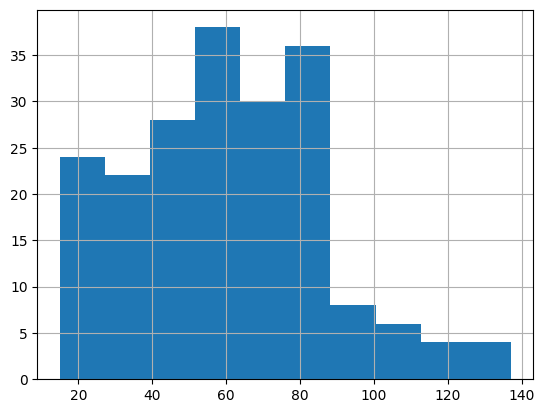

In [10]:
df.Ingreso.hist();

In [11]:
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme()

Text(0.5, 0, 'Ingreso en miles de USD')

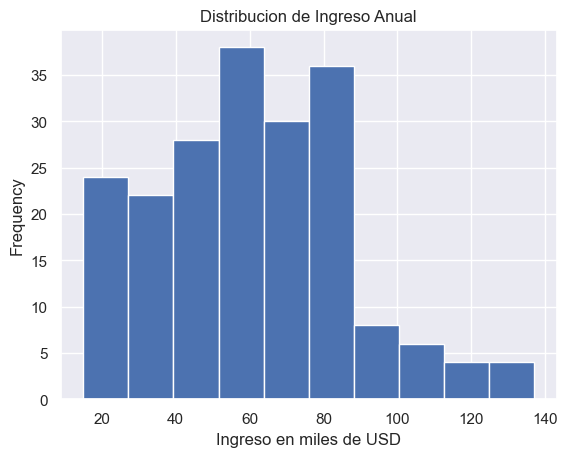

In [12]:
df.Ingreso.plot.hist();
plt.title('Distribucion de Ingreso Anual')
plt.xlabel('Ingreso en miles de USD')

## **Reglas a seguir**
- Si ingreso < 50 entonces '**Ingreso bajo**'
- Si 50 <= Ingreso <= 90 entonces '**Ingreso moderado**'
- Si ingreso > 90 '**Ingreso alto**'

In [13]:
df['Segmento'] = np.where(df.Ingreso>= 90, 'Ingreso alto', np.where(df.Ingreso < 50, 'Ingreso bajo', 'Ingreso moderado'));

In [14]:
df

,Genero,Edad,Ingreso,Gasto,Segmento
CustomerID,,,,,
1,Male,19,15,39,Ingreso bajo
2,Male,21,15,81,Ingreso bajo
3,Female,20,16,6,Ingreso bajo
4,Female,23,16,77,Ingreso bajo
5,Female,31,17,40,Ingreso bajo
...,...,...,...,...,...
196,Female,35,120,79,Ingreso alto
197,Female,45,126,28,Ingreso alto
198,Male,32,126,74,Ingreso alto


In [15]:
df.Segmento.value_counts()

Segmento
Ingreso moderado    106
Ingreso bajo         72
Ingreso alto         22
Name: count, dtype: int64

In [16]:
df.groupby('Segmento')['Ingreso'].describe().T

Segmento,Ingreso alto,Ingreso bajo,Ingreso moderado
count,22.000000,72.000000,106.000000
mean,108.181818,33.027778,69.377358
std,13.661334,11.091136,10.651584
min,93.000000,15.000000,50.000000
25%,98.250000,22.500000,61.000000
50%,103.000000,33.500000,70.000000
75%,118.250000,43.000000,78.000000
max,137.000000,49.000000,88.000000


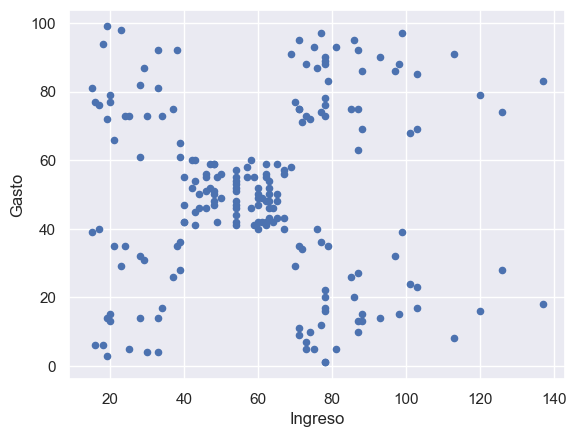

In [17]:
df.plot.scatter(x='Ingreso', y='Gasto');

## **Estandarizacion de datos (Escalado)**

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
col_escalar = ['Edad', 'Ingreso', 'Gasto']
datos_escalados = df.copy()
datos_escalados[col_escalar] = scaler.fit_transform(df[col_escalar])

In [21]:
df

,Genero,Edad,Ingreso,Gasto,Segmento
CustomerID,,,,,
1,Male,19,15,39,Ingreso bajo
2,Male,21,15,81,Ingreso bajo
3,Female,20,16,6,Ingreso bajo
4,Female,23,16,77,Ingreso bajo
5,Female,31,17,40,Ingreso bajo
...,...,...,...,...,...
196,Female,35,120,79,Ingreso alto
197,Female,45,126,28,Ingreso alto
198,Male,32,126,74,Ingreso alto


In [22]:
datos_escalados

,Genero,Edad,Ingreso,Gasto,Segmento
CustomerID,,,,,
1,Male,-1.424569,-1.738999,-0.434801,Ingreso bajo
2,Male,-1.281035,-1.738999,1.195704,Ingreso bajo
3,Female,-1.352802,-1.700830,-1.715913,Ingreso bajo
4,Female,-1.137502,-1.700830,1.040418,Ingreso bajo
5,Female,-0.563369,-1.662660,-0.395980,Ingreso bajo
...,...,...,...,...,...
196,Female,-0.276302,2.268791,1.118061,Ingreso alto
197,Female,0.441365,2.497807,-0.861839,Ingreso alto
198,Male,-0.491602,2.497807,0.923953,Ingreso alto


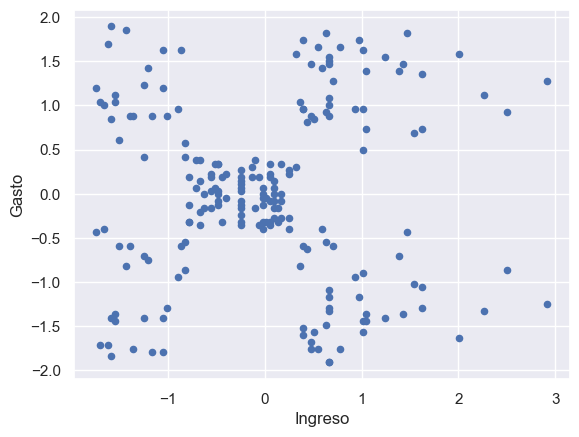

In [23]:
datos_escalados.plot.scatter(x='Ingreso', y='Gasto');

## **Uso de kmeans**

In [24]:
from sklearn.cluster import KMeans

In [25]:
modelo = KMeans(n_clusters=5, random_state=16)
modelo.fit(datos_escalados[col_escalar])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",16
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [26]:
datos_escalados['Segmento K'] = modelo.predict(datos_escalados[col_escalar])
datos_escalados

,Genero,Edad,Ingreso,Gasto,Segmento,Segmento K
CustomerID,,,,,,
1,Male,-1.424569,-1.738999,-0.434801,Ingreso bajo,2
2,Male,-1.281035,-1.738999,1.195704,Ingreso bajo,3
3,Female,-1.352802,-1.700830,-1.715913,Ingreso bajo,2
4,Female,-1.137502,-1.700830,1.040418,Ingreso bajo,3
5,Female,-0.563369,-1.662660,-0.395980,Ingreso bajo,2
...,...,...,...,...,...,...
196,Female,-0.276302,2.268791,1.118061,Ingreso alto,1
197,Female,0.441365,2.497807,-0.861839,Ingreso alto,4
198,Male,-0.491602,2.497807,0.923953,Ingreso alto,1


In [27]:
datos_escalados['Segmento K'].value_counts()

Segmento K
0    59
2    47
1    39
4    33
3    22
Name: count, dtype: int64

In [28]:
marcador = ['x', '*', '.', '|', ' ']

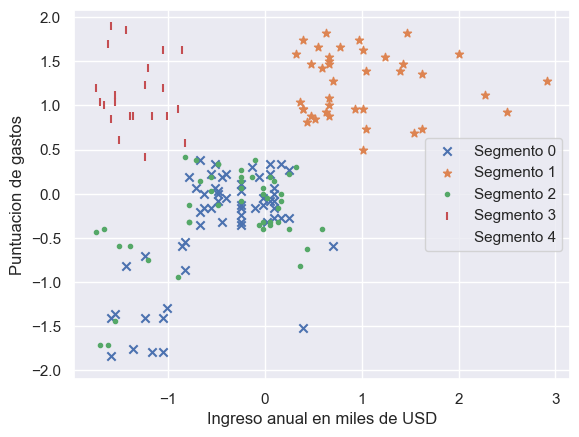

In [29]:
for segmento in range(5):
    temporal = datos_escalados[datos_escalados['Segmento K'] == segmento]
    plt.scatter(temporal['Ingreso'], temporal['Gasto'], marker=marcador[segmento], label=f'Segmento {segmento}')
plt.xlabel('Ingreso anual en miles de USD')
plt.ylabel('Puntuacion de gastos')
plt.legend();

In [30]:
datos_escalados[col_escalar].head()

,Edad,Ingreso,Gasto
CustomerID,,,
1,-1.424569,-1.738999,-0.434801
2,-1.281035,-1.738999,1.195704
3,-1.352802,-1.700830,-1.715913
4,-1.137502,-1.700830,1.040418
5,-0.563369,-1.662660,-0.395980


In [31]:
from mpl_toolkits import mplot3d

In [32]:
# %matplotlib notebook
%matplotlib widget

In [33]:
print(datos_escalados['Segmento'].value_counts())
datos_escalados.head()

Segmento
Ingreso moderado    106
Ingreso bajo         72
Ingreso alto         22
Name: count, dtype: int64


,Genero,Edad,Ingreso,Gasto,Segmento,Segmento K
CustomerID,,,,,,
1,Male,-1.424569,-1.738999,-0.434801,Ingreso bajo,2
2,Male,-1.281035,-1.738999,1.195704,Ingreso bajo,3
3,Female,-1.352802,-1.700830,-1.715913,Ingreso bajo,2
4,Female,-1.137502,-1.700830,1.040418,Ingreso bajo,3
5,Female,-0.563369,-1.662660,-0.395980,Ingreso bajo,2


In [34]:
from sklearn.preprocessing import LabelEncoder

In [35]:
codificador = LabelEncoder()
datos_escalados['Segmento'] = codificador.fit_transform(datos_escalados['Segmento'])
datos_escalados.head()

,Genero,Edad,Ingreso,Gasto,Segmento,Segmento K
CustomerID,,,,,,
1,Male,-1.424569,-1.738999,-0.434801,1,2
2,Male,-1.281035,-1.738999,1.195704,1,3
3,Female,-1.352802,-1.700830,-1.715913,1,2
4,Female,-1.137502,-1.700830,1.040418,1,3
5,Female,-0.563369,-1.662660,-0.395980,1,2


In [36]:
datos_escalados.Segmento.value_counts()

Segmento
2    106
1     72
0     22
Name: count, dtype: int64

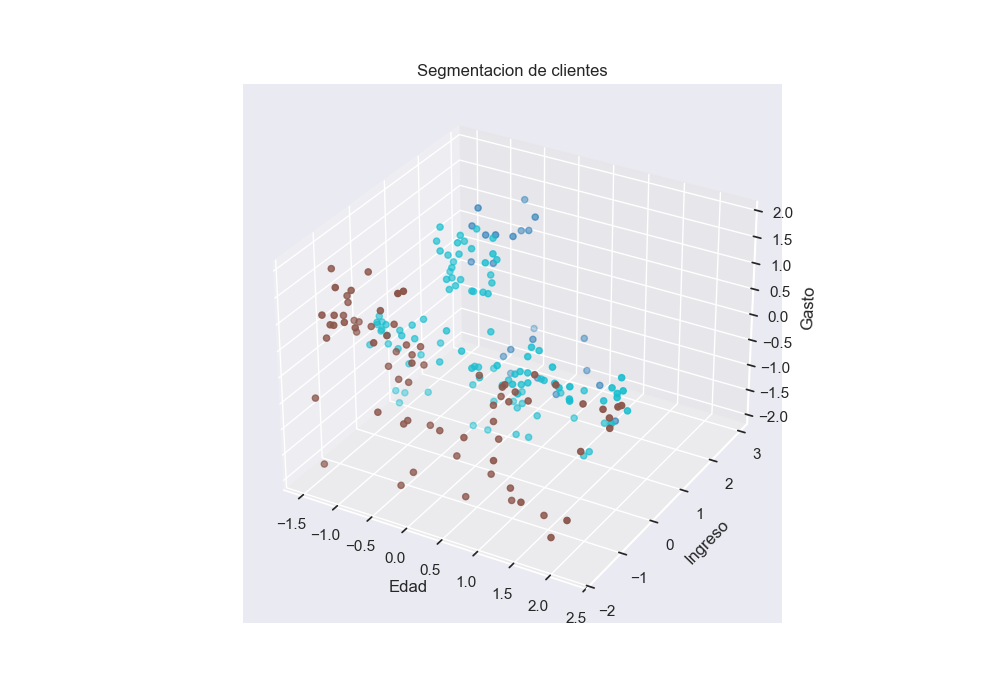

In [46]:
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection='3d')
ax.scatter3D(datos_escalados['Edad'], datos_escalados['Ingreso'], datos_escalados['Gasto'], c=datos_escalados['Segmento'], cmap='tab10');
plt.title('Segmentacion de clientes');
plt.xlabel('Edad');
plt.ylabel('Ingreso');
ax.set_zlabel('Gasto');
plt.show()

In [42]:
print(datos_escalados['Segmento K'].value_counts())
datos_escalados.head()

Segmento K
0    59
2    47
1    39
4    33
3    22
Name: count, dtype: int64


,Genero,Edad,Ingreso,Gasto,Segmento,Segmento K
CustomerID,,,,,,
1,Male,-1.424569,-1.738999,-0.434801,1,2
2,Male,-1.281035,-1.738999,1.195704,1,3
3,Female,-1.352802,-1.700830,-1.715913,1,2
4,Female,-1.137502,-1.700830,1.040418,1,3
5,Female,-0.563369,-1.662660,-0.395980,1,2


In [43]:
codificador_k = LabelEncoder()
datos_escalados['Segmento K'] = codificador_k.fit_transform(datos_escalados['Segmento K'])
datos_escalados.head()

,Genero,Edad,Ingreso,Gasto,Segmento,Segmento K
CustomerID,,,,,,
1,Male,-1.424569,-1.738999,-0.434801,1,2
2,Male,-1.281035,-1.738999,1.195704,1,3
3,Female,-1.352802,-1.700830,-1.715913,1,2
4,Female,-1.137502,-1.700830,1.040418,1,3
5,Female,-0.563369,-1.662660,-0.395980,1,2


In [44]:
datos_escalados['Segmento K'].value_counts()

Segmento K
0    59
2    47
1    39
4    33
3    22
Name: count, dtype: int64

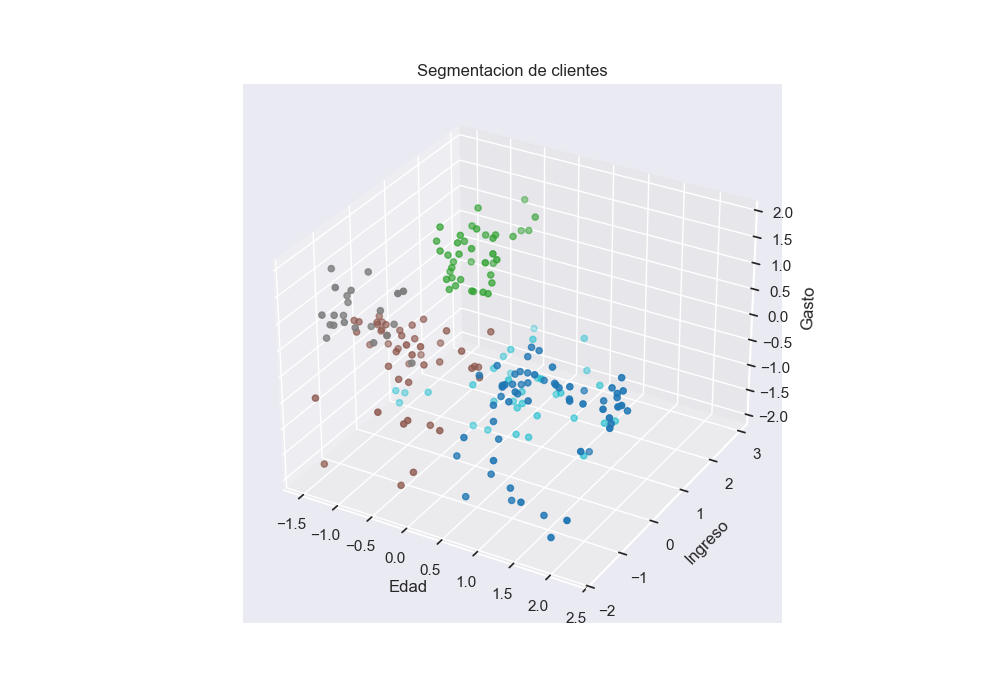

In [47]:
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection='3d')
ax.scatter3D(datos_escalados['Edad'], datos_escalados['Ingreso'], datos_escalados['Gasto'], c=datos_escalados['Segmento K'], cmap='tab10');
plt.title('Segmentacion de clientes');
plt.xlabel('Edad');
plt.ylabel('Ingreso');
ax.set_zlabel('Gasto');
plt.show()